In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, '..')

# 02 — Preprocessing Pipelines
Visualize the effect of Pipeline A (MI feature selection), Pipeline B (PCA), and Pipeline C (Wavelet + PCA) on each dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.data_loader import get_all_datasets
from src.preprocessing import get_pipelines, build_pipeline_a, build_pipeline_b, build_pipeline_c
from src.utils import RANDOM_STATE

datasets = get_all_datasets()

2026-05-15 18:50:20,056 — Bonn dataset files not found. Using synthetic fallback (500, 4097).
2026-05-15 18:50:20,057 — Generating synthetic Bonn-like data for development...


In [3]:
# Show dimensionality reduction per pipeline per dataset
rows = []
for name, (X, y) in datasets.items():
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    pipelines = get_pipelines(name)
    for pipe_name, pipe in pipelines.items():
        X_t = pipe.fit_transform(X_tr, y_tr)
        rows.append({
            'Dataset': name,
            'Pipeline': pipe_name,
            'Input Features': X_tr.shape[1],
            'Output Features': X_t.shape[1],
            'Reduction %': f'{(1 - X_t.shape[1]/X_tr.shape[1])*100:.1f}%',
        })

pd.DataFrame(rows)

,Dataset,Pipeline,Input Features,Output Features,Reduction %
0,uci_seizure,A,178,20,88.8%
1,uci_seizure,B,178,39,78.1%
2,bonn_eeg,A,4097,20,99.5%
3,bonn_eeg,B,4097,363,91.1%
4,bonn_eeg,C,4097,63,98.5%
5,eeg_eye_state,A,14,14,0.0%
6,eeg_eye_state,B,14,5,64.3%


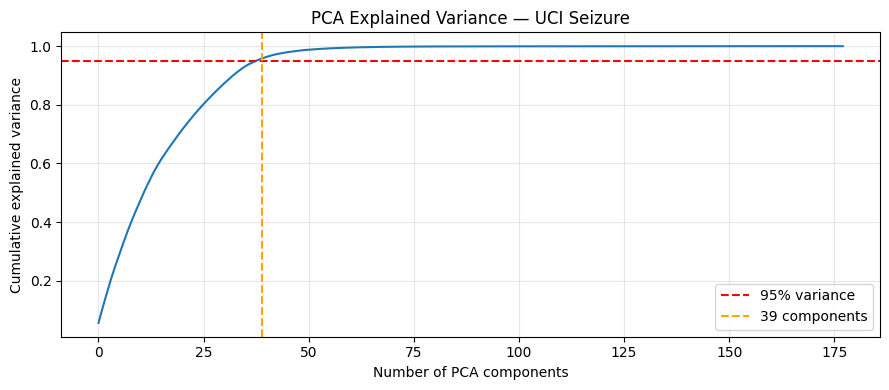

Components needed for 95% variance: 39


In [4]:
# PCA explained variance for Pipeline B on UCI Seizure
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_uci, y_uci = datasets['uci_seizure']
X_scaled = StandardScaler().fit_transform(X_uci)
pca = PCA().fit(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = np.searchsorted(cumvar, 0.95) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cumvar, linewidth=1.5)
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.axvline(n95, color='orange', linestyle='--', label=f'{n95} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA Explained Variance — UCI Seizure')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/pca_explained_variance.png', dpi=150)
plt.show()
print(f'Components needed for 95% variance: {n95}')

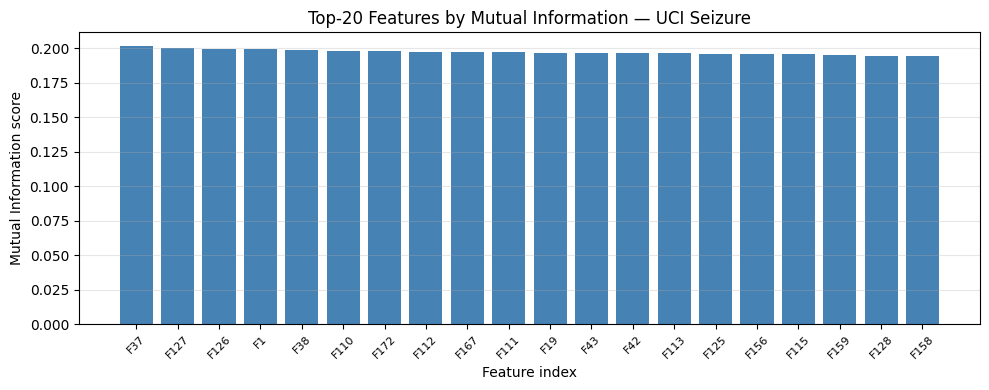

In [5]:
# MI feature importance for Pipeline A on UCI Seizure
from sklearn.feature_selection import mutual_info_classif

X_uci, y_uci = datasets['uci_seizure']
X_scaled = StandardScaler().fit_transform(X_uci)
mi_scores = mutual_info_classif(X_scaled, y_uci, random_state=RANDOM_STATE)

top20_idx = np.argsort(mi_scores)[::-1][:20]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(20), mi_scores[top20_idx], color='steelblue')
ax.set_xticks(range(20))
ax.set_xticklabels([f'F{i}' for i in top20_idx], rotation=45, fontsize=8)
ax.set_xlabel('Feature index')
ax.set_ylabel('Mutual Information score')
ax.set_title('Top-20 Features by Mutual Information — UCI Seizure')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/mi_feature_importance.png', dpi=150)
plt.show()

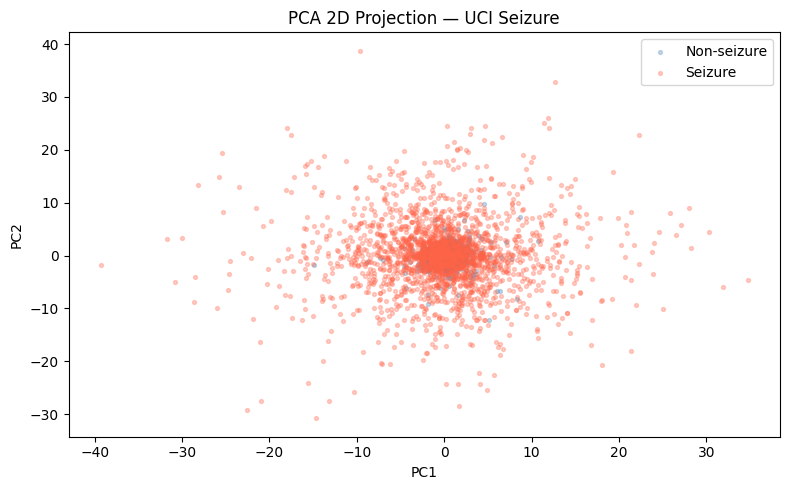

In [6]:
# 2D PCA scatter — UCI Seizure (Pipeline B output)
pipe_b = build_pipeline_b()
X_uci, y_uci = datasets['uci_seizure']
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(StandardScaler().fit_transform(X_uci))

fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0, 'steelblue', 'Non-seizure'), (1, 'tomato', 'Seizure')]:
    mask = y_uci == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, alpha=0.3, s=8)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA 2D Projection — UCI Seizure')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/pca_2d_uci.png', dpi=150)
plt.show()